# Gradient Descent

Gradient Descent is an optimization algorithm used to train machine learning models.

It helps us find the best model parameters by minimizing the prediction error.

Most ML algorithms including neural networks learn using Gradient Descent.

Notebook structure:

Concept  
Math  
Visualization  
Code  
Experiment  
Summary

## Concept

When we train a machine learning model, we want the predictions to be as close as possible to the real values.

To measure how wrong our model is, we use a **cost function**.

The goal is simple:

Find parameters that minimize the cost.

Gradient Descent works like a person walking down a mountain.

Imagine standing on a mountain in fog.  
You cannot see the valley, but you can feel which direction slopes downward.

You take small steps downward until you reach the lowest point.

Gradient Descent works exactly the same way:

1. Start with random parameters
2. Measure error
3. Move parameters in the direction that reduces error
4. Repeat until error becomes very small

## Math Behind Gradient Descent

We update parameters using the formula:

θ = θ − α ∂J(θ)/∂θ

Where:

θ = model parameters  
α = learning rate  
J(θ) = cost function

Explanation:

∂J(θ)/∂θ tells us the direction of the steepest slope.

Gradient Descent moves parameters slightly in the opposite direction of the slope.

The learning rate determines how big the step is.

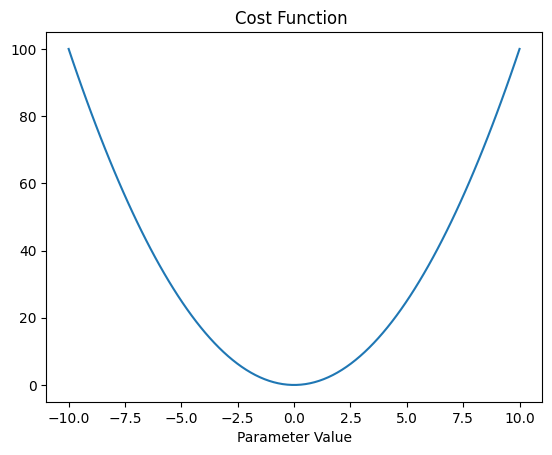

In [1]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(-10, 10, 100)

cost = theta**2


plt.plot(theta, cost)
plt.title("Cost Function ")
plt.xlabel("Parameter Value")
plt.show()


Explanation:

The lowest point of the curve is the minimum cost.

Gradient Descent tries to find this point.

In [2]:
learning_rate = 0.01

theta = 8

history = []

for i in range(20):

  gradient = 2 * theta

  theta = theta - learning_rate * gradient

  history.append(theta)

print("Fixed parameter: ", theta)




Fixed parameter:  5.340863774040756


Explanation:

The lowest point of the curve is the minimum cost.

Gradient Descent tries to find this point.

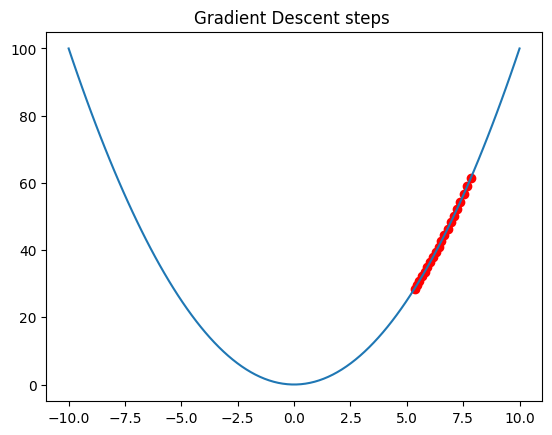

In [3]:
theta_vals = np.linspace(-10, 10, 100)

cost_vals = theta_vals**2

plt.plot(theta_vals, cost_vals)
points = history
plt.scatter(points, [p**2 for p in points],color='red')

plt.title("Gradient Descent steps ")
plt.show()


Explanation:

Each red point shows how the algorithm moves toward the minimum.

In [5]:
def gradient_descent(lr):
  theta = 8
  values = []

  for i in range(20):
    gradient =  2 * theta

    theta = theta - lr * gradient

    values . append(theta)

  return values

lr_small = gradient_descent(0.01)
lr_good = gradient_descent(0.1)
lr_big = gradient_descent(0.5)

print("Small LR Model ", lr_small[-1])
print("Good LR Model ", lr_good[-1])
print("Big LR Model ", lr_big [-1])

Small LR Model  5.340863774040756
Good LR Model  0.09223372036854777
Big LR Model  0.0


Explanation:

Learning rate controls how fast the model learns.

Too small → slow training
Too large → unstable training

## Summary

Gradient Descent is the algorithm used to train most machine learning models.

Key ideas:

• It minimizes the cost function  
• It updates parameters step-by-step  
• Learning rate controls step size  

Update rule:

θ = θ − α ∂J(θ)/∂θ

Gradient Descent is the foundation of modern machine learning.

Neural networks, deep learning models, and large language models all rely on this principle.

# Types of Gradient Descent

In real machine learning systems, gradient descent can be implemented in different ways depending on how much data we use for each parameter update.

The three main types are:

1. Batch Gradient Descent  
2. Stochastic Gradient Descent (SGD)  
3. Mini-Batch Gradient Descent

The difference between them depends on how many training samples are used to compute the gradient.

## Concept

Batch Gradient Descent
Uses the entire dataset to compute the gradient before updating parameters.

Stochastic Gradient Descent
Updates parameters using one training example at a time.

Mini-Batch Gradient Descent
Updates parameters using small groups of training data called batches.

Comparison

Batch GD
Very stable but slow for large datasets.

SGD
Very fast but noisy.

Mini-Batch GD
Balanced approach and used in most deep learning models.

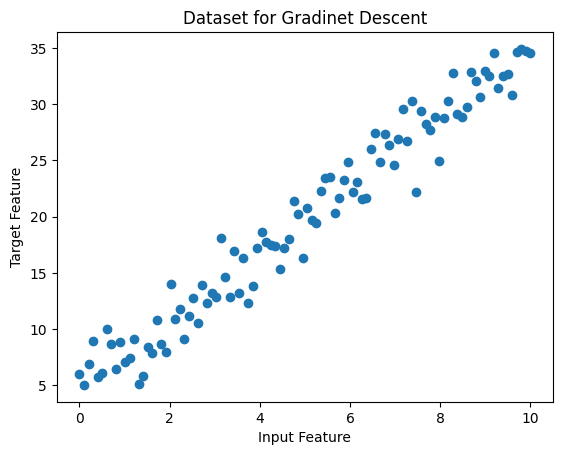

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(0,10,100)
y = 3*X + 5 + np.random.normal(0,2,100)

plt.scatter(X,y)

plt.title("Dataset for Gradinet Descent")
plt.xlabel("Input Feature")
plt.ylabel("Target Feature")

plt.show()

Explanation:

This creates a dataset where we will test different gradient descent methods.

In [9]:
theta = 0
learning_rate = 0.001
epochs = 100

theta_history_batch = []

for epoch in range(epochs):

  prediction = theta * X
  errors = prediction - y
  gradient = (2/len(X)) * np.sum(errors * X)

  theta = theta - learning_rate * gradient

  theta_history_batch.append(theta)

  print("Final Parameter from BatchGD", theta )

Final Parameter from BatchGD 0.24940223463562064
Final Parameter from BatchGD 0.48209367981249085
Final Parameter from BatchGD 0.6991940146896314
Final Parameter from BatchGD 0.901747896152445
Final Parameter from BatchGD 1.0907299855576493
Final Parameter from BatchGD 1.2670496386693735
Final Parameter from BatchGD 1.4315552813537464
Final Parameter from BatchGD 1.5850384920872136
Final Parameter from BatchGD 1.7282378109230512
Final Parameter from BatchGD 1.861842293244299
Final Parameter from BatchGD 1.9864948254032815
Final Parameter from BatchGD 2.1027952182021163
Final Parameter from BatchGD 2.211303093099615
Final Parameter from BatchGD 2.3125405750326014
Final Parameter from BatchGD 2.406994804809135
Final Parameter from BatchGD 2.4951202831629313
Final Parameter from BatchGD 2.577341057748241
Final Parameter from BatchGD 2.65405276359871
Final Parameter from BatchGD 2.725624526868626
Final Parameter from BatchGD 2.7924007410170892
Final Parameter from BatchGD 2.854702723981868

Concept:

Batch GD calculates gradient using all 100 samples before updating.

In [15]:
theta = 0
learning_rate = 0.001
epochs = 100

theta_history_sgd = []

for epoch in range(epochs):

    for i in range(len(X)):

        prediction = theta * X[i]

        error = prediction - y[i]

        gradient = 2 * error * X[i]

        theta = theta - learning_rate * gradient

    theta_history_sgd.append(theta)

print("Final parameter from SGD:", theta)

Final parameter from SGD: 3.5002519020702327


Concept:

SGD updates after every data point.

This makes learning faster but noisy.

In [16]:
theta = 0
epochs = 100
learning_rate = 0.001
batch_Size = 10

theta_history = []

for epoch in range(epochs):

  for i in range(0,len(X),batch_Size):

    X_batch = X[i:i+batch_Size]
    y_batch = y[i:i+batch_Size]

    prediction = theta * X_batch
    errors = prediction - y_batch

    gradient = (2/len(X_batch)) * np.sum(errors * X_batch)

    theta = theta - learning_rate * gradient

    theta_history.append(theta)

    print("Final parameter from Mini-Batch GD:", theta)


Final parameter from Mini-Batch GD: 0.007081829799771393
Final parameter from Mini-Batch GD: 0.03029105571558927
Final parameter from Mini-Batch GD: 0.08940610734710043
Final parameter from Mini-Batch GD: 0.19064971014103688
Final parameter from Mini-Batch GD: 0.3447435615540098
Final parameter from Mini-Batch GD: 0.5657379422747696
Final parameter from Mini-Batch GD: 0.8379015433409609
Final parameter from Mini-Batch GD: 1.1562797246037624
Final parameter from Mini-Batch GD: 1.5140304432392366
Final parameter from Mini-Batch GD: 1.8747459577666585
Final parameter from Mini-Batch GD: 1.8807374853565257
Final parameter from Mini-Batch GD: 1.895592589024835
Final parameter from Mini-Batch GD: 1.9315460044351713
Final parameter from Mini-Batch GD: 1.9877369663422584
Final parameter from Mini-Batch GD: 2.0689095238269357
Final parameter from Mini-Batch GD: 2.185109938245687
Final parameter from Mini-Batch GD: 2.319525306168224
Final parameter from Mini-Batch GD: 2.4698470506250803
Final pa

Concept:

Mini-batch uses small chunks of data.

This is what deep learning frameworks actually use.

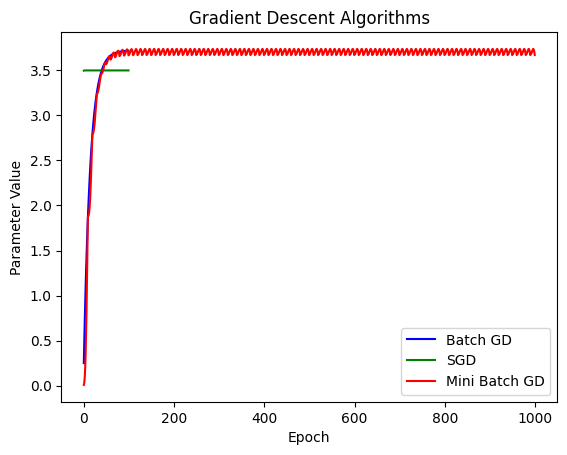

In [20]:
plt.plot(theta_history_batch, label='Batch GD', color='blue')
plt.plot(theta_history_sgd, label='SGD', color='green')
plt.plot(theta_history , label = "Mini Batch GD", color='red')
plt.legend()

plt.title("Gradient Descent Algorithms")
plt.xlabel("Epoch")
plt.ylabel("Parameter Value" )
plt.show()

This graph shows how fast each method converges.

## Training Flow

Batch GD
Dataset → Compute Gradient → Update Parameters

SGD
Sample → Gradient → Update → Next Sample

Mini Batch GD
Small Batch → Gradient → Update → Next Batch

Mini-Batch Gradient Descent is the most commonly used method in modern machine learning systems.

## Summary

In this notebook we studied Gradient Descent and its variants.

Batch Gradient Descent
Uses the full dataset for each update.

Stochastic Gradient Descent
Updates parameters after every sample.

Mini-Batch Gradient Descent
Uses small batches of data and is widely used in modern ML systems.

These optimization methods are used to train most machine learning models including neural networks.

# Loss Surface Visualization

To understand gradient descent deeply, we need to visualize how the cost function behaves.

The cost function can be imagined as a surface or landscape where:

- Height represents error
- Lowest point represents minimum error

Gradient descent moves across this landscape toward the lowest point.

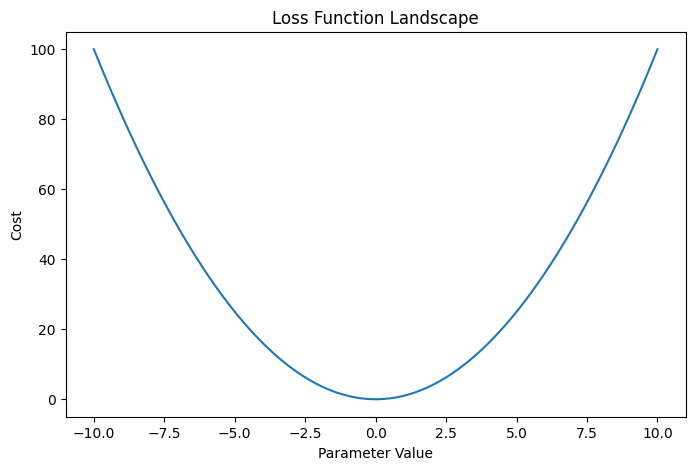

In [23]:
import numpy as np
import matplotlib.pyplot as plt

theta_vals = np.linspace(-10,10,100)

cost_vals = theta_vals**2

plt.figure(figsize=(8,5))

plt.plot(theta_vals,cost_vals)

plt.title("Loss Function Landscape")
plt.xlabel("Parameter Value")
plt.ylabel("Cost")

plt.show()

Explanation :

The curve represents the error surface

The lowest point represents optimal parameter

In [24]:
theta = 0
learning_rate = 0.01

theta_history = []

for i in range(20):

  graident = 2 *  theta
  theta = theta - gradient * learning_rate
  theta_history.append(theta)


This simulates how gradient descent moves toward the minimum.

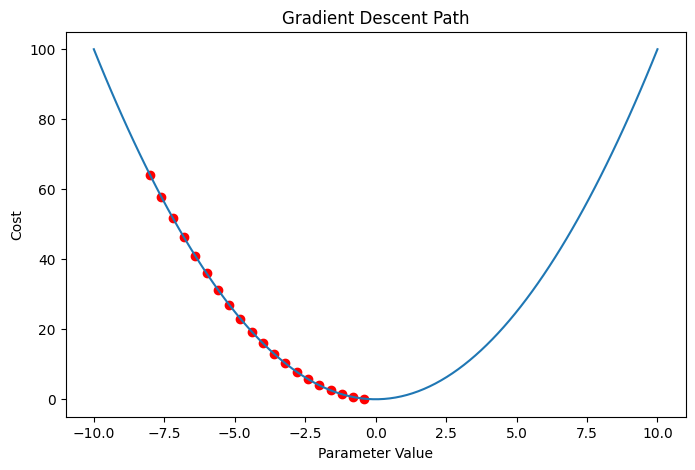

In [25]:
theta_vals = np.linspace(-10,10,100)
cost_vals = theta_vals**2

plt.figure(figsize=(8,5))

plt.plot(theta_vals,cost_vals)

plt.scatter(theta_history,[t**2 for t in theta_history],color="red")

plt.title("Gradient Descent Path")

plt.xlabel("Parameter Value")
plt.ylabel("Cost")

plt.show()

Explanation:

Each red dot represents one training step.

The model moves closer to the minimum error.

In [27]:
def gradient_descent(lr):

  theta = 8
  path = []

  for i in range(15):

    gradient = 2 * theta
    theta = theta - lr * gradient

    path.append(theta)

  return path

lr_small = gradient_descent(0.01)
lr_good = gradient_descent(0.1)
lr_big = gradient_descent(0.5)

print("Small LR final ", lr_small[-1])
print("Good LR final " , lr_good[-1])
print("large LR final ", lr_big[-1])

Small LR final  5.908552821163231
Good LR final  0.281474976710656
large LR final  0.0


Explanation:

Learning rate controls how fast the model learns.

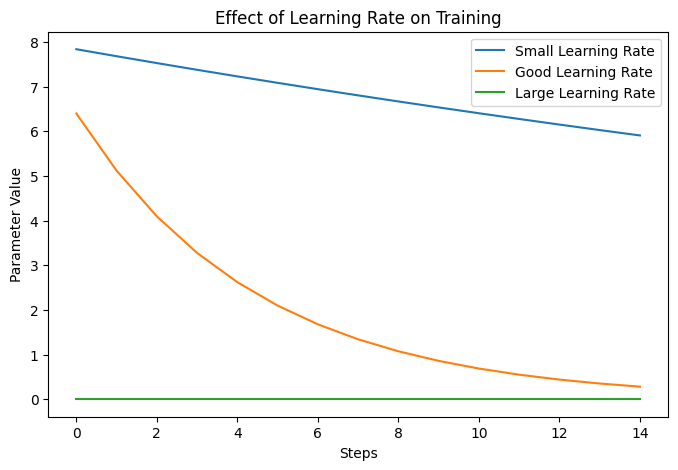

In [29]:
plt.figure(figsize=(8,5))

plt.plot(lr_small,label="Small Learning Rate")
plt.plot(lr_good,label="Good Learning Rate")
plt.plot(lr_big,label="Large Learning Rate")

plt.legend()

plt.title("Effect of Learning Rate on Training")

plt.xlabel("Steps")
plt.ylabel("Parameter Value")

plt.show()

Interpretation:

Small LR → very slow learning

Large LR → unstable learning

Balanced LR → optimal training

# Gradient Descent — Final Summary

Gradient Descent is the core optimization algorithm used in machine learning.

Key ideas:

- Models learn by minimizing a cost function
- Gradients indicate the direction of steepest increase
- Gradient descent moves in the opposite direction

We explored:

Basic gradient descent  
Batch gradient descent  
Stochastic gradient descent  
Mini-batch gradient descent  
Loss landscape visualization  
Learning rate effects

These ideas form the foundation of training modern ML and deep learning models.